# Metrics + Data Viz for Qwen LID

In [2]:
#Necessary imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [3]:
DATASET = "../output/qwen_lid_few_shot_2026-07-12_15-44-17.csv" 
df = pd.read_csv(DATASET)

In [23]:
df.head()

,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,qwen_ner
0,0,post_0001,1,0,yabancı,TR,NaN,NaN,O
1,1,post_0001,1,1,bir,TR,NaN,NaN,O
2,2,post_0001,1,2,hocamızın,TR,NaN,NaN,O
3,3,post_0001,1,3,yarı,TR,NaN,NaN,O
4,4,post_0001,1,4,şaka,TR,NaN,NaN,O


## Qwen LID Results

In [25]:
df["qwen_langid"].value_counts()

qwen_ner
O          4457
B-PROD      105
I-PROD       49
B-ORG        49
B-TITLE      40
I-TITLE      35
B-TIME       21
B-PER        18
I-ORG        16
B-OTHER      15
B-LOC        14
I-PER        12
B-GROUP       6
I-TIME        3
I-OTHER       2
B-EVENT       2
I-GROUP       2
I-LOC         1
I-EVENT       1
Name: count, dtype: int64

In [ ]:
df.dropna(subset=["qwen_langid"], inplace=True)

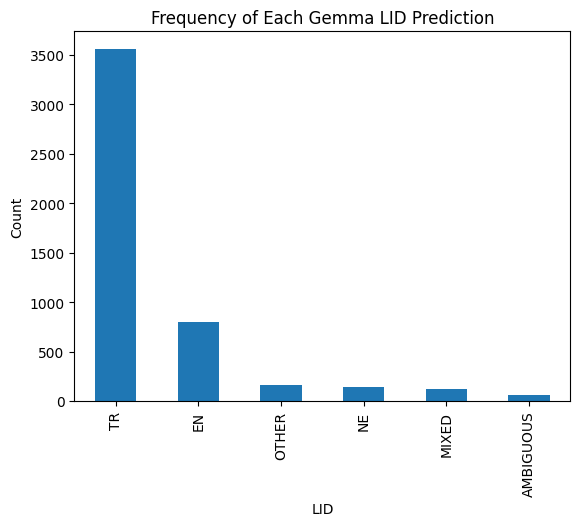

In [9]:
#Frequency of predictions
df['qwen_langid'].value_counts().plot(kind='bar')
plt.title('Frequency of Each Qwen LID Prediction')
plt.xlabel('LID')
plt.ylabel('Count')
plt.show()

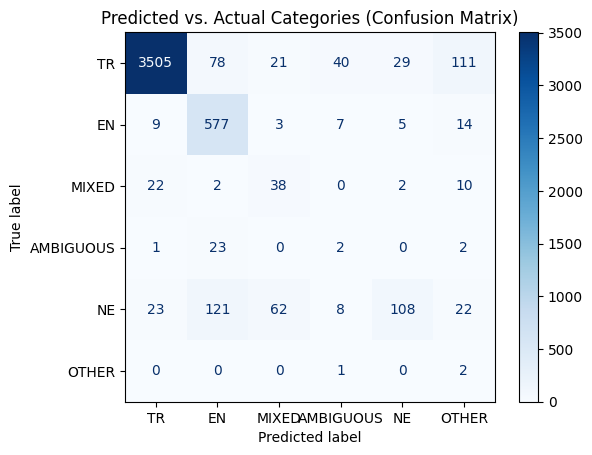

In [10]:
#Confusion matrix
cm = confusion_matrix(df['lid'], df['qwen_langid'], labels=["TR", "EN", "MIXED", "AMBIGUOUS", "NE", "OTHER", "UNK"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["TR", "EN", "MIXED", "AMBIGUOUS", "NE", "OTHER", "UNK"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [11]:
#Macro F1
macro_f1 = f1_score(df["lid"], df["qwen_langid"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.4445



In [12]:
#F1 Per Class
f1_per_class = f1_score(df["lid"], df["qwen_langid"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.04651163 0.81497175 0.38383838 0.44262295 0.02439024 0.9545207 ]



In [13]:
#Full Classification Report
print("Classification Report:")
print(classification_report(df["lid"], df["qwen_langid"]))

Classification Report:
              precision    recall  f1-score   support

   AMBIGUOUS       0.03      0.07      0.05        28
          EN       0.72      0.94      0.81       615
       MIXED       0.31      0.51      0.38        74
          NE       0.75      0.31      0.44       344
       OTHER       0.01      0.67      0.02         3
          TR       0.98      0.93      0.95      3784

    accuracy                           0.87      4848
   macro avg       0.47      0.57      0.44      4848
weighted avg       0.92      0.87      0.89      4848



In [14]:
mismatched_rows = df[df['lid'] != df['qwen_langid']]

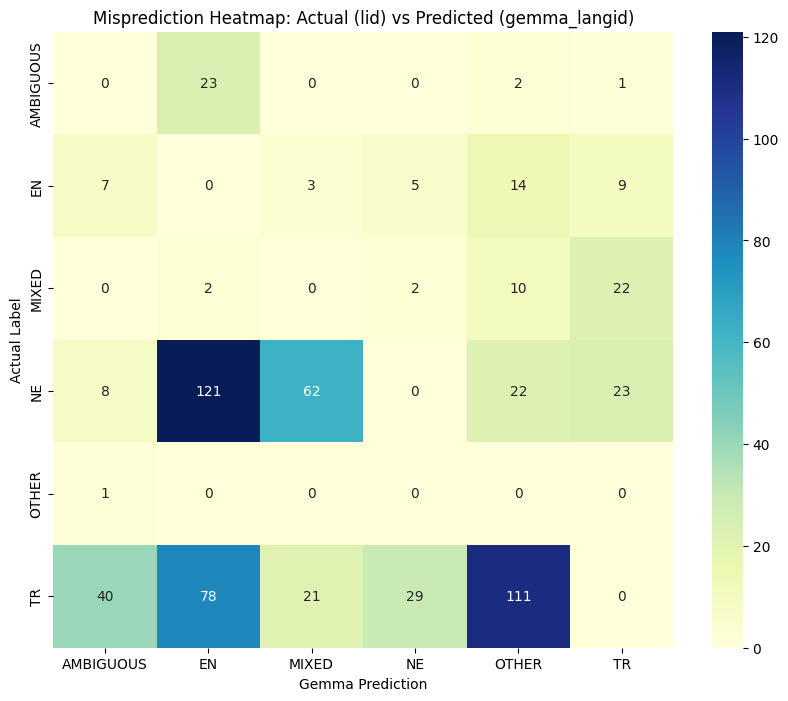

In [15]:
#Mismatched rows CM
cm = pd.crosstab(mismatched_rows['lid'], mismatched_rows['qwen_langid'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Misprediction Heatmap: Actual (lid) vs Predicted (qwen_langid)')
plt.ylabel('Actual Label')
plt.xlabel('Qwen Prediction')
plt.show()

In [16]:
mismatched_rows[mismatched_rows["lid"] == "MIXED"]

,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,gemma_langid
190,190,post_0008,1,2,group'un,MIXED,MIXED,NaN,TR
389,389,post_0016,1,5,conlarindan,MIXED,MIXED,NaN,TR
464,464,post_0019,4,0,lgbti,MIXED,MIXED,NaN,OTHER
570,570,post_0022,3,17,djim,MIXED,MIXED,NaN,OTHER
584,584,post_0022,4,10,djlik,MIXED,MIXED,NaN,TR
670,670,post_0027,4,3,mottom,MIXED,MIXED,NaN,OTHER
843,843,post_0031,1,4,veganlar,MIXED,MIXED,NaN,TR
995,995,post_0036,1,3,downloadla,MIXED,MIXED,NaN,TR
1075,1075,post_0039,4,2,historylerini,MIXED,MIXED,NaN,TR
1174,1174,post_002,1,42,toollar,MIXED,MIXED,O,OTHER
